#**ACTIVIDAD**

In [326]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import json
import geopandas as gpd
from IPython.display import display

In [327]:
datatype = {
    'ANIO_PRECIO': 'object',
    'MES_PRECIO' : 'object',
    'DIA_PRECIO' : 'object',
    'CODIGO_MUNICIPIO_DANE' : 'object',
}
correccion_nombres = {
    'SANTANDER' : 'SANTANDER',
    'CUNDINAMARCA': 'CUNDINAMARCA',
    'CALDAS' : 'CALDAS',
    'BOGOTA D.C.' : 'SANTAFE DE BOGOTA D.C',
    'VALLE DEL CAUCA': 'VALLE DEL CAUCA',
    'RISARALDA' : 'RISARALDA',
    'ATLANTICO': 'ATLANTICO',
    'TOLIMA': 'TOLIMA',
    'ANTIOQUIA': 'ANTIOQUIA',
    'QUINDIO': 'QUINDIO',

}

In [328]:
df = pd.read_csv("PreciosGasNaturalVehicula.csv", sep = ',', dtype = datatype)
df['DEPARTAMENTO_EDS'] = df['DEPARTAMENTO_EDS'].replace(correccion_nombres)
df['FECHA_PRECIO'] = pd.to_datetime(df['FECHA_PRECIO'], format='%Y-%m-%d')
df.head(n = 10)

,FECHA_PRECIO,ANIO_PRECIO,MES_PRECIO,DIA_PRECIO,DEPARTAMENTO_EDS,MUNICIPIO_EDS,NOMBRE_COMERCIAL_EDS,PRECIO_PROMEDIO_PUBLICADO,TIPO_COMBUSTIBLE,CODIGO_MUNICIPIO_DANE,LATITUD_MUNICIPIO,LONGITUD_MUNICIPIO
0,2024-09-01,2024,09,01,SANTANDER,BUCARAMANGA,CAMOVA,2299,GNCV,68001,7.155834,-73.111572
1,2024-07-01,2024,07,01,SANTANDER,BUCARAMANGA,CAMOVA,2249,GNCV,68001,7.155834,-73.111572
2,2024-10-01,2024,10,01,CUNDINAMARCA,CHIA,CHIA EDS - GNV,2787,GNCV,25175,4.857824,-74.038094
3,2024-10-01,2024,10,01,CALDAS,MANIZALES,ESTACIÓN DE SERVICIO CALDAS,3324,GNCV,17001,5.083433,-75.507278
4,2024-10-01,2024,10,01,SANTAFE DE BOGOTA D.C,"BOGOTA, D.C.",ESTACION DE SERVICIO COMBUSCOL EL DORADO,2718,GNCV,11001,4.652954,-74.083565
5,2024-10-01,2024,10,01,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIOS LAS CEIBAS CALI S.A.S.,3336,GNCV,76001,3.399044,-76.576492
6,2024-10-01,2024,10,01,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO TERPEL CAÑAVERALEJO - GNV,3367,GNCV,76001,3.399044,-76.576492
7,2024-10-01,2024,10,01,RISARALDA,PEREIRA,EDS SANTA HELENA,2869,GNCV,66001,4.803663,-75.795792
8,2024-10-01,2024,10,01,SANTAFE DE BOGOTA D.C,"BOGOTA, D.C.",ESTACION DE SERVICIO COMBUSCOL HEROES,2717,GNCV,11001,4.652954,-74.083565
9,2024-10-01,2024,10,01,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO AUTOMOTRIZ GUADUALES GNV,3367,GNCV,76001,3.399044,-76.576492


In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9863 entries, 0 to 9862
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   FECHA_PRECIO               9863 non-null   datetime64[ns]
 1   ANIO_PRECIO                9863 non-null   object        
 2   MES_PRECIO                 9863 non-null   object        
 3   DIA_PRECIO                 9863 non-null   object        
 4   DEPARTAMENTO_EDS           9863 non-null   object        
 5   MUNICIPIO_EDS              9863 non-null   object        
 6   NOMBRE_COMERCIAL_EDS       9863 non-null   object        
 7   PRECIO_PROMEDIO_PUBLICADO  9863 non-null   int64         
 8   TIPO_COMBUSTIBLE           9863 non-null   object        
 9   CODIGO_MUNICIPIO_DANE      9863 non-null   object        
 10  LATITUD_MUNICIPIO          9863 non-null   float64       
 11  LONGITUD_MUNICIPIO         9863 non-null   float64       
dtypes: dat

In [330]:
df['DEPARTAMENTO_EDS'].unique()

array(['SANTANDER', 'CUNDINAMARCA', 'CALDAS', 'SANTAFE DE BOGOTA D.C',
       'VALLE DEL CAUCA', 'RISARALDA', 'ATLANTICO', 'TOLIMA', 'ANTIOQUIA',
       'QUINDIO', 'MAGDALENA', 'CAUCA', 'BOLIVAR', 'CESAR', 'META',
       'SUCRE', 'CORDOBA', 'BOYACA', 'CASANARE', 'HUILA', 'CAQUETA',
       'LA GUAJIRA'], dtype=object)

In [331]:
df['DEPARTAMENTO_EDS'].nunique()

22

In [332]:
df['MUNICIPIO_EDS'].unique()

array(['BUCARAMANGA', 'CHIA', 'MANIZALES', 'BOGOTA, D.C.', 'CALI',
       'PEREIRA', 'BARRANQUILLA', 'PALMIRA', 'IBAGUE', 'MEDELLIN',
       'CALARCA', 'ARMENIA', 'SANTA MARTA', 'POPAYAN',
       'CARTAGENA DE INDIAS', 'BELLO', 'VALLEDUPAR', 'TULUA', 'BARBOSA',
       'BOSCONIA', 'MOSQUERA', 'MALAMBO', 'PUERTO COLOMBIA', 'CUMARAL',
       'COROZAL', 'COTA', 'PLANETA RICA', 'SOACHA', 'SOPO', 'YUMBO',
       'PIEDECUESTA', 'DUITAMA', 'APARTADO', 'CHIQUINQUIRA', 'SABANETA',
       'RIONEGRO', 'YOPAL', 'SOGAMOSO', 'SAHAGUN', 'MONTERIA', 'SOLEDAD',
       'JAMUNDI', 'BARRANCABERMEJA', 'SOTAQUIRA', 'ITAGUI',
       'VILLAVICENCIO', 'CARTAGO', 'TUNJA', 'CIENAGA', 'DOSQUEBRADAS',
       'GIRON', 'NEIVA', 'SINCELEJO', 'LA DORADA', 'ENVIGADO',
       'FACATATIVA', 'PAILITAS', 'FLORIDABLANCA', 'AGUAZUL', 'ARMERO',
       'ESPINAL', 'GUADALAJARA DE BUGA', 'SANTANDER DE QUILICHAO',
       'FLORENCIA', 'VENADILLO', 'GIRARDOT', 'LA UNION', 'BUENAVENTURA',
       'LA MESA', 'FUNZA', 'GUARNE', 'TURBACO

In [333]:
df.groupby('DEPARTAMENTO_EDS')['MUNICIPIO_EDS'].unique()

DEPARTAMENTO_EDS
ANTIOQUIA                [MEDELLIN, BELLO, APARTADO, SABANETA, RIONEGRO...
ATLANTICO                [BARRANQUILLA, MALAMBO, PUERTO COLOMBIA, SOLEDAD]
BOLIVAR                           [CARTAGENA DE INDIAS, TURBACO, MAGANGUE]
BOYACA                   [DUITAMA, CHIQUINQUIRA, SOGAMOSO, SOTAQUIRA, T...
CALDAS                                   [MANIZALES, LA DORADA, CHINCHINA]
CAQUETA                                                        [FLORENCIA]
CASANARE                                  [YOPAL, AGUAZUL, PAZ DE ARIPORO]
CAUCA                                    [POPAYAN, SANTANDER DE QUILICHAO]
CESAR                          [VALLEDUPAR, BOSCONIA, PAILITAS, AGUACHICA]
CORDOBA                                  [PLANETA RICA, SAHAGUN, MONTERIA]
CUNDINAMARCA             [CHIA, MOSQUERA, COTA, SOACHA, SOPO, FACATATIV...
HUILA                                                              [NEIVA]
LA GUAJIRA                                                      [RIOHACHA]
MAGDALEN

In [334]:
df.groupby('DEPARTAMENTO_EDS')['MUNICIPIO_EDS'].nunique()

DEPARTAMENTO_EDS
ANTIOQUIA                10
ATLANTICO                 4
BOLIVAR                   3
BOYACA                    5
CALDAS                    3
CAQUETA                   1
CASANARE                  3
CAUCA                     2
CESAR                     4
CORDOBA                   3
CUNDINAMARCA             11
HUILA                     1
LA GUAJIRA                1
MAGDALENA                 3
META                      2
QUINDIO                   2
RISARALDA                 2
SANTAFE DE BOGOTA D.C     1
SANTANDER                 7
SUCRE                     3
TOLIMA                    4
VALLE DEL CAUCA          12
Name: MUNICIPIO_EDS, dtype: int64

In [335]:
df['ANIO_PRECIO'].unique()

array(['2024', '2025', '2022', '2023', '2021'], dtype=object)

In [336]:
sorted(df['MES_PRECIO'].unique())

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']

In [337]:
df['DIA_PRECIO'].unique()

array(['01'], dtype=object)

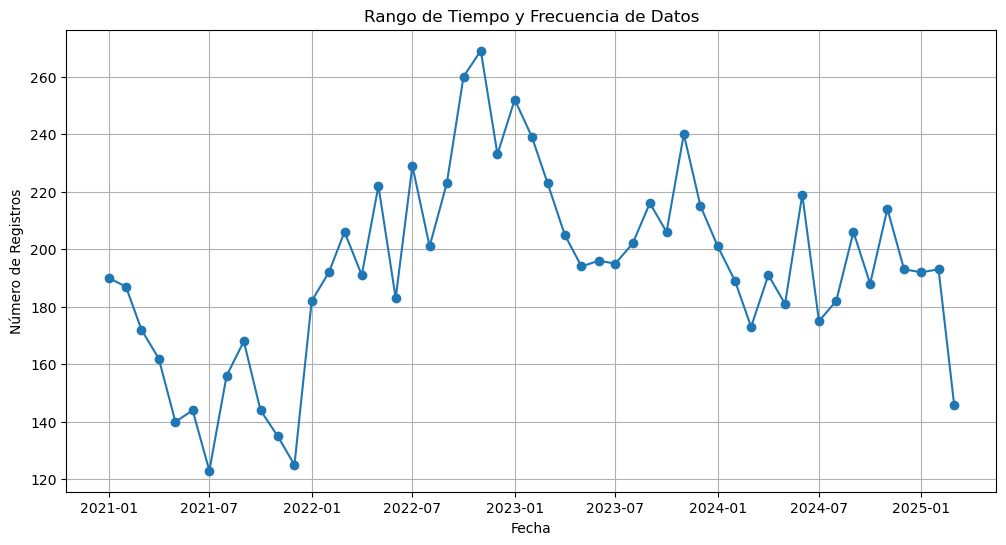

In [338]:
conteo_fechas = df['FECHA_PRECIO'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(conteo_fechas.index, conteo_fechas.values, marker='o', linestyle='-')
plt.title('Rango de Tiempo y Frecuencia de Datos')
plt.xlabel('Fecha')
plt.ylabel('Número de Registros')
plt.grid(True)
plt.show()

In [339]:
df_2021 = df.query("FECHA_PRECIO.dt.year == 2021")
df_2022 = df.query("FECHA_PRECIO.dt.year == 2022")
df_2023 = df.query("FECHA_PRECIO.dt.year == 2023")
df_2024 = df.query("FECHA_PRECIO.dt.year == 2024")
df_2025 = df.query("FECHA_PRECIO.dt.year == 2025")

In [340]:
precios2021 = df_2021.groupby(['DEPARTAMENTO_EDS','MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)
display(precios2021)

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS      MUNICIPIO_EDS                                 
ANTIOQUIA             APARTADO                               1811.00
                      BELLO                                  1794.06
                      ITAGUI                                 1793.00
                      MEDELLIN                               1808.33
                      RIONEGRO                               1870.32
                      SABANETA                               1815.00
ATLANTICO             BARRANQUILLA                           1559.55
                      PUERTO COLOMBIA                        1595.42
                      SOLEDAD                                1573.17
BOLIVAR               CARTAGENA DE INDIAS                    1648.55
                      MAGANGUE                               1549.00
                      TURBACO                                1677.00
BOYACA                CHIQUINQUIRA                           1228.43
                      DUITAMA                                1690.00
                      SOGAMOSO                               1264.00
                      TUNJA                                  1626.93
CALDAS                CHINCHINA                              1990.00
                      MANIZALES                              1961.06
CASANARE              YOPAL                                  1762.50
CAUCA                 POPAYAN                                2050.57
CESAR                 BOSCONIA                               1581.73
                      VALLEDUPAR                             1353.09
CORDOBA               MONTERIA                               1745.26
                      PLANETA RICA                           1649.00
                      SAHAGUN                                1549.00
CUNDINAMARCA          CHIA                                   1736.09
                      COTA                                   1780.88
                      FACATATIVA                             1809.00
                      FUNZA                                  1809.00
                      MOSQUERA                               1810.80
                      SOACHA                                 1700.50
                      SOPO                                   1832.33
HUILA                 NEIVA                                  1945.50
MAGDALENA             SANTA MARTA                            1646.00
META                  CUMARAL                                1589.00
                      VILLAVICENCIO                          1690.00
QUINDIO               ARMENIA                                2074.00
                      CALARCA                                2074.00
RISARALDA             DOSQUEBRADAS                           1784.59
                      PEREIRA                                1792.00
SANTAFE DE BOGOTA D.C BOGOTA, D.C.                           1708.31
SANTANDER             BARBOSA                                1763.50
                      BUCARAMANGA                            1687.00
                      FLORIDABLANCA                          1747.20
                      GIRON                                  1651.09
                      LEBRIJA                                1799.00
SUCRE                 COROZAL                                1839.00
                      SINCELEJO                              1619.92
TOLIMA                IBAGUE                                 1743.72
                      VENADILLO                              1850.00
VALLE DEL CAUCA       BUENAVENTURA                           1987.00
                      CALI                                   1787.48
                      CARTAGO                                2040.00
                      FLORIDA                                1980.00
                      GUADALAJARA DE BUGA                    1627.00
                      JAMUNDI                                1810.00
                      LA UNION           

In [341]:
precios2022 = df_2022.groupby(['DEPARTAMENTO_EDS','MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)
display(precios2022)

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS MUNICIPIO_EDS                           
ANTIOQUIA        APARTADO                         2020.00
                 BARBOSA                          2066.25
                 BELLO                            2059.37
                 ENVIGADO                         2251.67
                 ITAGUI                           2178.77
...                                                   ...
VALLE DEL CAUCA  LA UNION                         2121.43
                 PALMIRA                          2231.28
                 ROLDANILLO                       2199.09
                 TULUA                            2279.06
                 YUMBO                            1956.18

[68 rows x 1 columns]

In [342]:
df_2023.groupby(['DEPARTAMENTO_EDS','MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS MUNICIPIO_EDS                                 
ANTIOQUIA        APARTADO                               2421.82
                 BARBOSA                                2413.33
                 BELLO                                  2421.92
                 ENVIGADO                               2418.50
                 GUARNE                                 2530.00
...                                                         ...
VALLE DEL CAUCA  GUADALAJARA DE BUGA                    2047.18
                 JAMUNDI                                2390.00
                 PALMIRA                                2619.50
                 TULUA                                  2609.85
                 YUMBO                                  2327.17

[74 rows x 1 columns]

In [343]:
df_2024.groupby(['DEPARTAMENTO_EDS','MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS MUNICIPIO_EDS                           
ANTIOQUIA        APARTADO                         2591.82
                 BARBOSA                          2662.22
                 BELLO                            2785.92
                 ENVIGADO                         2805.83
                 ITAGUI                           2844.00
...                                                   ...
VALLE DEL CAUCA  JAMUNDI                          2885.00
                 PALMIRA                          3029.28
                 RIOFRIO                          2511.00
                 TULUA                            2939.00
                 YUMBO                            2560.22

[70 rows x 1 columns]

In [344]:
df_2025.groupby(['DEPARTAMENTO_EDS','MUNICIPIO_EDS']).agg({
    'PRECIO_PROMEDIO_PUBLICADO': 'mean'
}).round(2)

PRECIO_PROMEDIO_PUBLICADO
DEPARTAMENTO_EDS MUNICIPIO_EDS                           
ANTIOQUIA        APARTADO                         3190.00
                 BARBOSA                          3990.00
                 BELLO                            3706.43
                 ENVIGADO                         3523.33
                 ITAGUI                           3540.00
...                                                   ...
VALLE DEL CAUCA  LA UNION                         3300.00
                 PALMIRA                          3529.00
                 RIOFRIO                          2990.00
                 TULUA                            3400.62
                 YUMBO                            2746.00

[64 rows x 1 columns]

In [345]:
# Cargar el GeoJSON con los departamentos de Colombia
geojson_url = 'https://raw.githubusercontent.com/lihkir/Uninorte/main/AppliedStatisticMS/DataVisualizationRPython/Lectures/Python/PythonDataSets/Colombia.geo.json'
colombia_geo = gpd.read_file(geojson_url)
colombia_geo['NOMBRE_DPT'] = colombia_geo['NOMBRE_DPT'].str.upper()

def graficar_precios_por_departamento(df, year):
    # Crear una copia y asegurar nombres de departamentos en mayúsculas
    df = df.copy()
    df['DEPARTAMENTO_EDS'] = df['DEPARTAMENTO_EDS'].str.upper()
    
    # Calcular el promedio por departamento
    precios = df.groupby('DEPARTAMENTO_EDS').agg({
        'PRECIO_PROMEDIO_PUBLICADO': 'mean'
    }).round(2).reset_index()

    # Unir con el GeoDataFrame
    merged = colombia_geo.merge(precios, left_on='NOMBRE_DPT', right_on='DEPARTAMENTO_EDS', how='left')
    merged['PRECIO_PROMEDIO_PUBLICADO'] = merged['PRECIO_PROMEDIO_PUBLICADO'].fillna(0)

    # Plotear el mapa
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = 'viridis' 

    merged.plot(column='PRECIO_PROMEDIO_PUBLICADO',
                 cmap=cmap,
                 linewidth=0.8,
                 edgecolor='0.8',
                 legend=True,
                 ax=ax)

    ax.set_title(f'Precios Promedio Publicado por Departamento en {year}', fontsize=16)
    ax.axis('off')

    # Agregar nombres de los departamentos
    for idx, row in merged.iterrows():
        if not pd.isna(row['PRECIO_PROMEDIO_PUBLICADO']):
            plt.annotate(text=row['NOMBRE_DPT'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                         fontsize=6, ha='center', color='black')

    plt.tight_layout()
    plt.show()

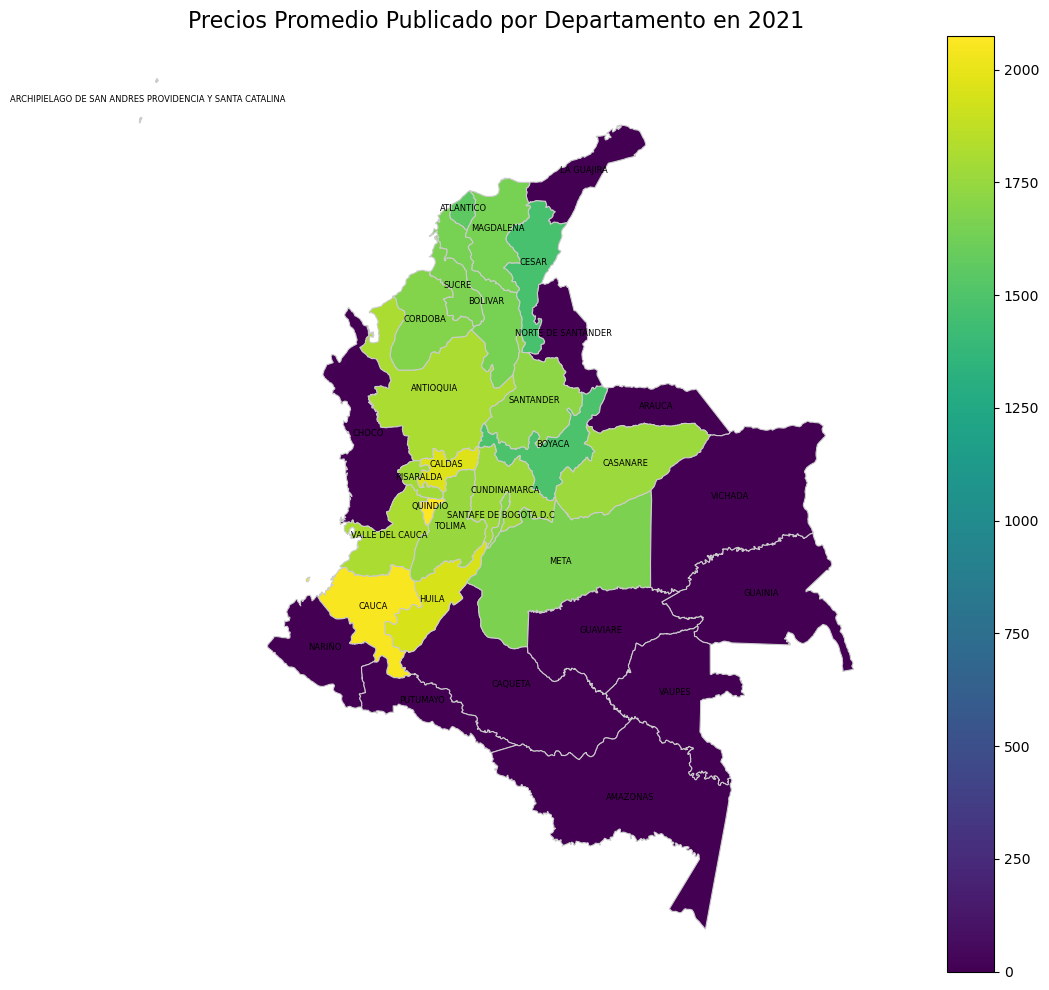

In [346]:
graficar_precios_por_departamento(df_2021, 2021)

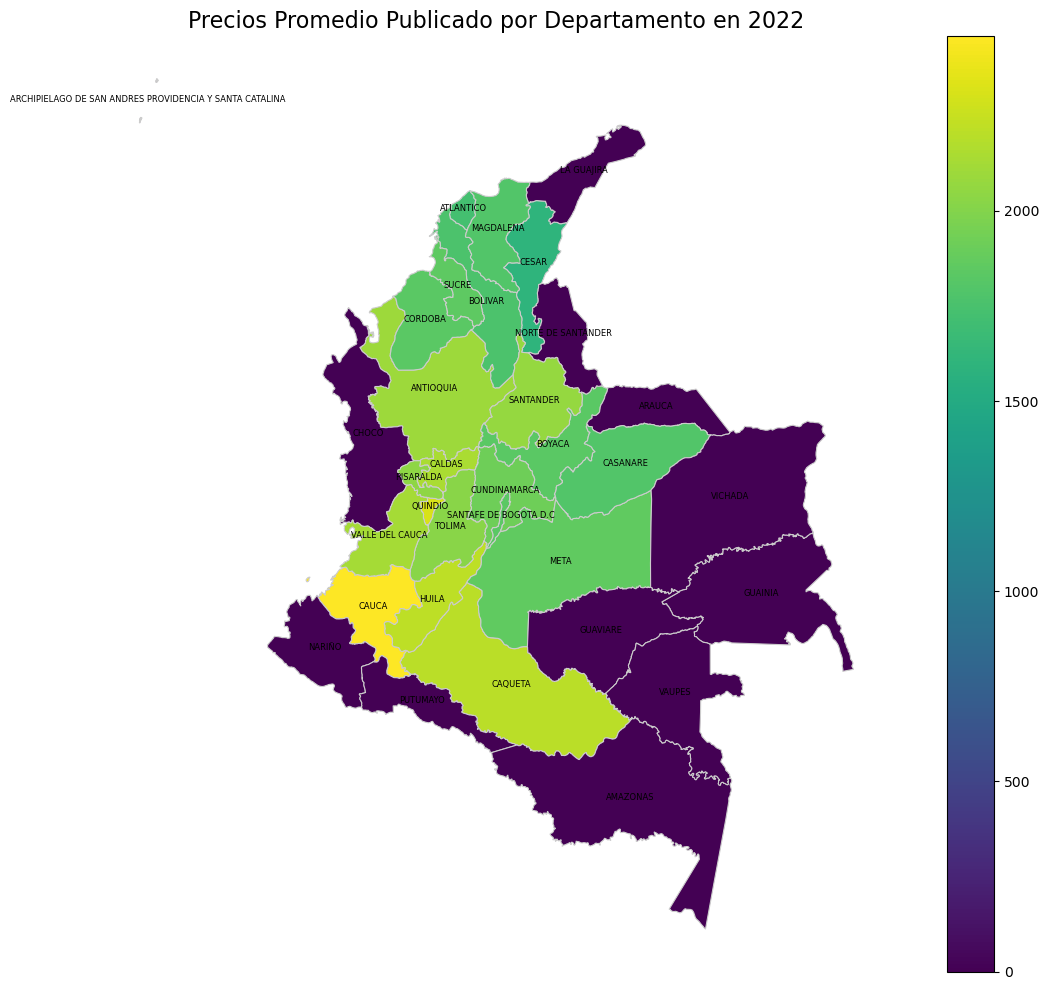

In [347]:
graficar_precios_por_departamento(df_2022, 2022)

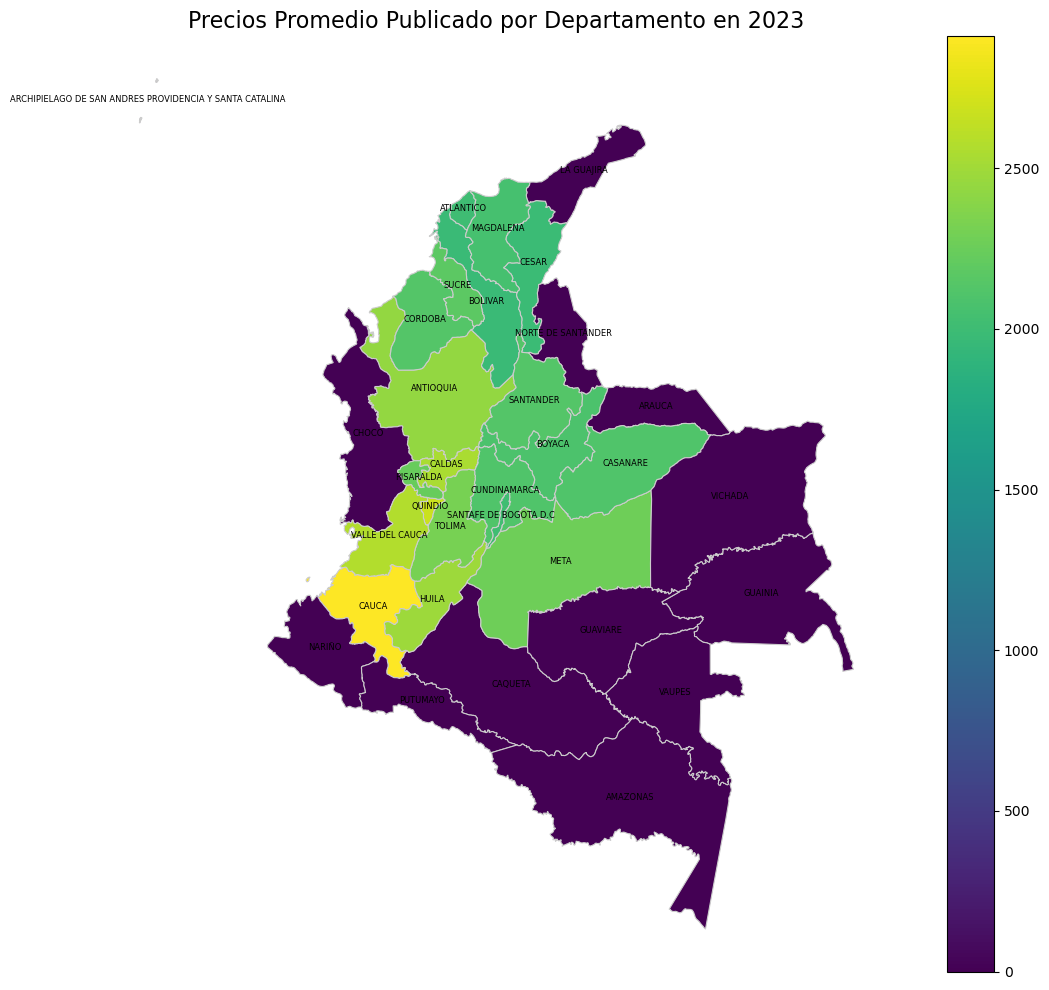

In [348]:
graficar_precios_por_departamento(df_2023, 2023)

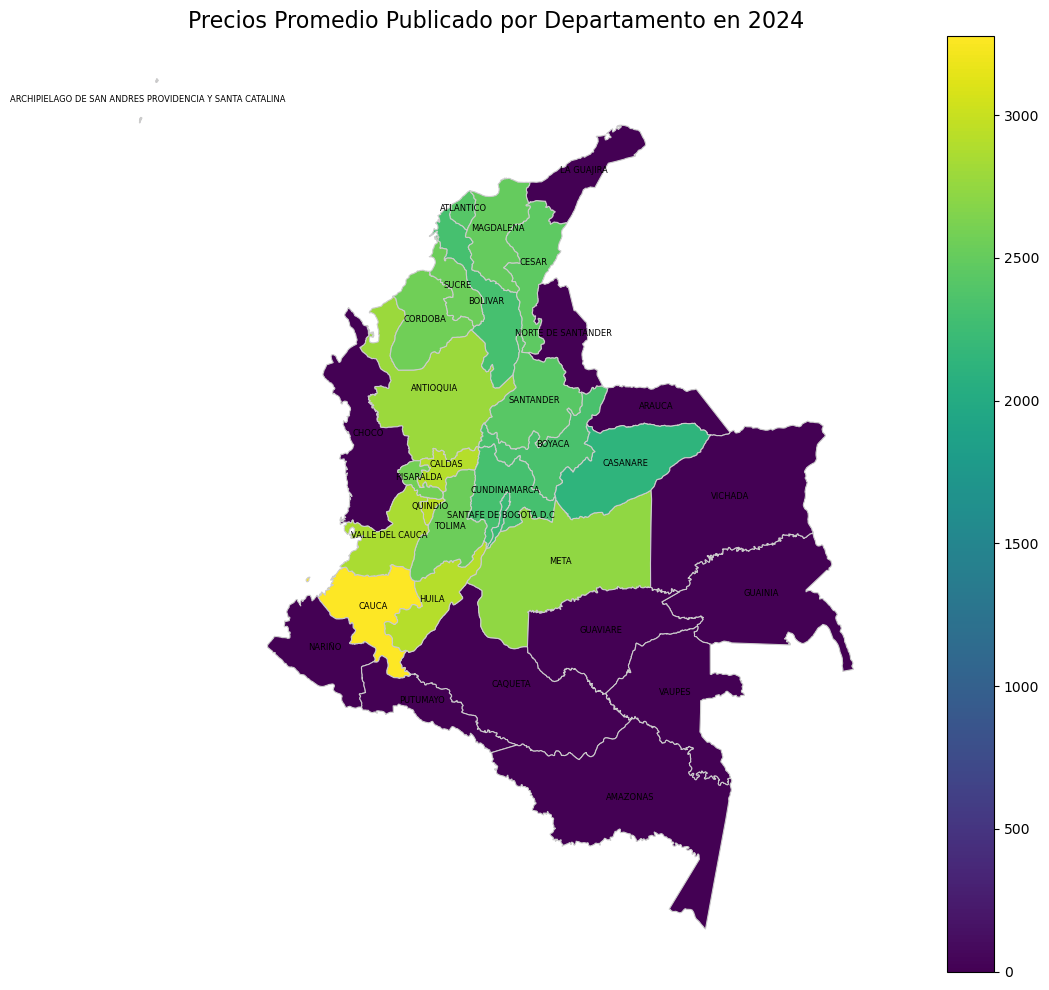

In [349]:
graficar_precios_por_departamento(df_2024, 2024)

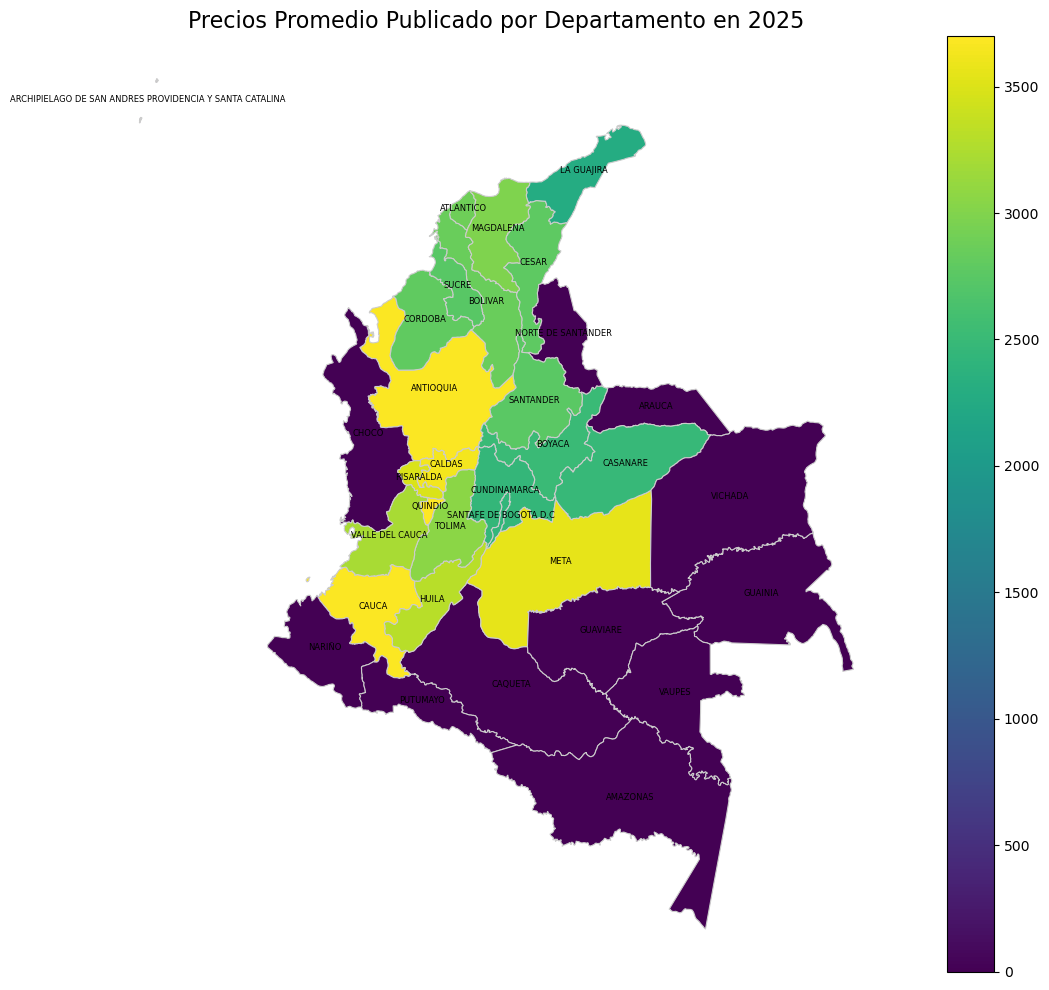

In [350]:
graficar_precios_por_departamento(df_2025, 2025)